In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('pokemon_data.csv')
df['Type 2'] = df['Type 2'].fillna('None')
avg_atc = df.groupby('Type 1')['Attack'].mean().sort_values(ascending = False)
avg_def = df.groupby('Type 1')['Defense'].mean().sort_values(ascending = False).head(3)
avg_hp = df.groupby('Type 1')['HP'].mean().sort_values(ascending = False).head(3)
avg_speed = df.groupby('Type 1')['Speed'].mean().sort_values(ascending = False).head(3)
print(avg_atc)



Type 1
Dragon      112.125000
Fighting     96.777778
Ground       95.750000
Rock         92.863636
Steel        92.703704
Dark         88.387097
Fire         84.769231
Flying       78.750000
Poison       74.678571
Water        74.151786
Ghost        73.781250
Normal       73.469388
Grass        73.214286
Ice          72.750000
Psychic      71.456140
Bug          70.971014
Electric     69.090909
Fairy        61.529412
Name: Attack, dtype: float64


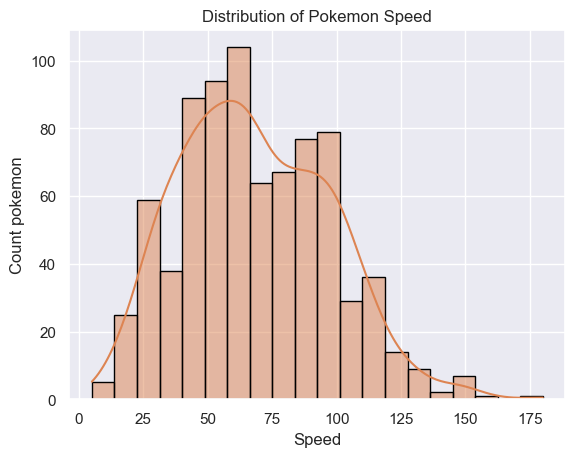

In [30]:
sns.histplot ()
plt.title('Distribution of Pokemon Speed') 
sns.histplot (df["Speed"], bins = 20,edgecolor="black",kde = True)
plt.xlabel('Speed')
plt.ylabel('Count pokemon')
plt.show()

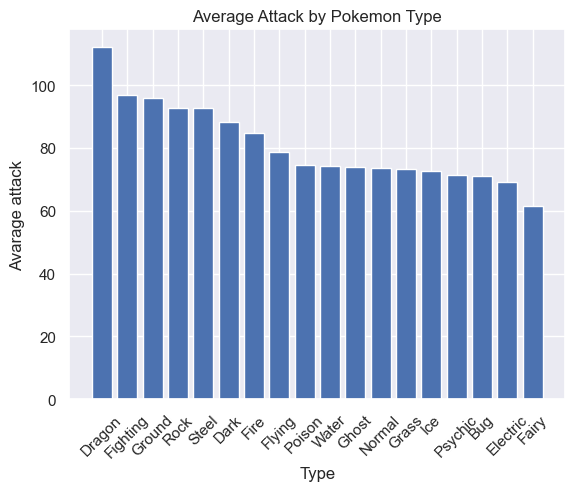

In [32]:

plt.title('Average Attack by Pokemon Type')
plt.bar(avg_atc.index, avg_atc.values)
plt.xlabel('Type')
plt.ylabel('Avarage attack')
plt.xticks(rotation=45)
plt.show()

<Axes: >

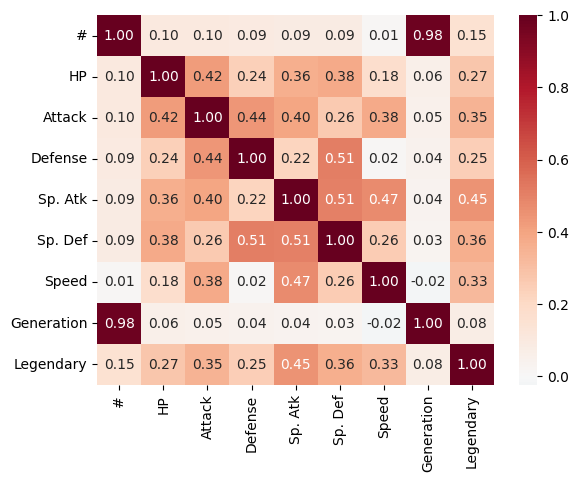

In [26]:

corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'RdBu_r',  center=0)

<Axes: xlabel='Generation', ylabel='HP'>

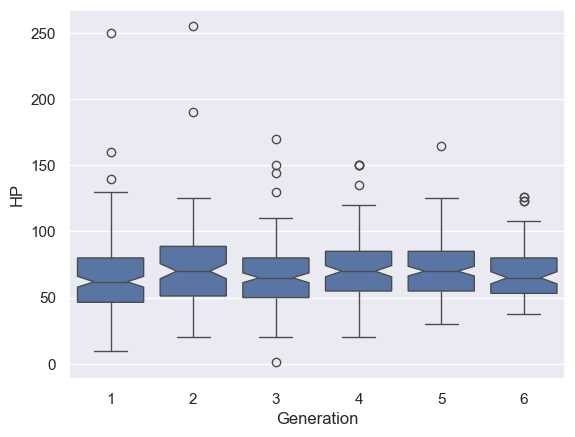

In [41]:
sns.boxplot(x = 'Generation', y = 'HP',data = df, width = 0.8, notch = True, showfliers = True)


<Axes: xlabel='Attack', ylabel='Defense'>

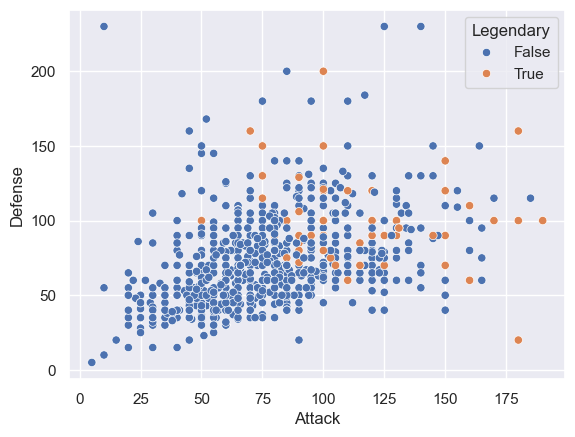

In [48]:
sns.scatterplot(x = 'Attack', y = 'Defense',hue = 'Legendary', data = df)

In [56]:
#Які покемони з Generation 1 мають Attack > 100
print(df.loc[(df['Generation'] ==1) & (df['Attack'] >= 100)].sort_values('Attack',ascending = False))

       #                       Name    Type 1    Type 2   HP  Attack  Defense  \
163  150        MewtwoMega Mewtwo X   Psychic  Fighting  106     190      100   
141  130      GyaradosMega Gyarados     Water      Dark   95     155      109   
137  127          PinsirMega Pinsir       Bug    Flying   65     155      120   
19    15      BeedrillMega Beedrill       Bug    Poison   65     150       40   
164  150        MewtwoMega Mewtwo Y   Psychic      None  106     150       70   
154  142  AerodactylMega Aerodactyl      Rock    Flying   80     135       85   
161  149                  Dragonite    Dragon    Flying   91     134       95   
120  112                     Rhydon    Ground      Rock  105     130      120   
147  136                    Flareon      Fire      None   65     130       60   
7      6  CharizardMega Charizard X      Fire    Dragon   78     130      111   
74    68                    Machamp  Fighting      None   90     130       80   
107   99                    

In [75]:
#Чи є суттєва різниця в Total між Legendary і звичайними
df['Total'] = df['HP'] + df['Attack'] + df['Defense'] + df['Sp. Atk'] + df['Sp. Def'] + df['Speed']
print('Показник колонки Total для звичайних покемонів', int(df.loc[df['Legendary'] == False]['Total'].mean()))
print('Показник колонки Total для легендарних покемонів покемонів',int(df.loc[df['Legendary'] == True]['Total'].mean()))
print(int(df.loc[df['Legendary'] == True]['Total'].mean() - df.loc[df['Legendary'] == False]['Total'].mean())/
      int(df.loc[df['Legendary'] == True]['Total'].mean())* 100)
#як можна помітити після запуску в легендарних покемонів колонка Total більша на 34.5 відсотків 

Показник колонки Total для звичайних покемонів 417
Показник колонки Total для легендарних покемонів покемонів 637
34.53689167974882


In [98]:
#Який тип найчастіше зустрічається у топ-50 покемонів за Total
df_50  = df.sort_values('Total', ascending=False).head(50)
print(df_50.groupby('Type 1')['Name'].count().sort_values(ascending=False))

Type 1
Dragon      11
Psychic      7
Water        6
Steel        5
Fire         4
Rock         4
Normal       3
Ghost        2
Grass        2
Ground       2
Dark         1
Electric     1
Fairy        1
Fighting     1
Name: Name, dtype: int64


Найсильніший тип покемонів — Dragon. Він з'являється 11 разів у топ-50 за показником Total, а також має аномально високу середню силу атаки порівняно з іншими типами (це можна побачити на графіку "Average Attack by Pokemon Type").
Легендарні покемони значно сильніші за звичайних — середнє значення Total у легендарних покемонів на 34.5% вище.
HP майже не змінюється між поколіннями — медіана стабільна на рівні 60–70 у всіх шести поколіннях.
При роботі з даним датасетом Mega-форми покемонів не враховувались, оскільки вони мають однаковий номер з базовою формою і можуть спотворити результати аналізу.